# Tweet Sentiment Analysis - Apple and Google Products

**Phase 4 Project | Natural Language Processing**

Members = Angela Mukami, Moffat Mwangi, Catherine Nanjala, Tafford Pessah

---

## Summary
 
<to be entered later>

---

## Section 1 - Business Problem

Technology companies like Apple and Google receive thousands of tweets daily. The social media and customer experience teams need a way to automatically sort incoming tweets by sentiment so they can:

- Quickly identify and respond to negative feedback before it escalates
- Track positive sentiment trends around product launches
- Filter out neutral tweets that require no action

The goal of this project is to build a model that can classify the sentiment of a tweet as positive, negative, or neutral based on its text content. This is a multiclass text classification problem solved using Natural Language Processing (NLP) techniques.

**Stakeholder:** Social media and customer experience team at a technology company

**Business Question:** Can we automatically classify the sentiment of a tweet about Apple or Google products using its text content?

**Success Metric:** Weighted F1 score, which balances precision and recall across all three classes and accounts for the unequal class sizes in this dataset.

---

## Section 2 - Imports

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

print('All imports successful.')

All imports successful.


---

## Section 3 - Data Understanding

We begin by loading the dataset and examining its structure, column names, class distribution, and missing values. Understanding the data at this stage directly informs the preparation decisions we will make in the next section.

In [4]:
# Load the dataset
# The file uses latin1 encoding due to special characters in some tweets
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='latin1')

print('Shape:', df.shape)
print()
df.head()

Shape: (9093, 3)



,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [5]:
# Rename columns for easier reference throughout the notebook
df.columns = ['tweet_text', 'brand_product', 'sentiment']

print('Column names updated.')
df.head()

Column names updated.


,tweet_text,brand_product,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
tweet_text          1
brand_product    5802
sentiment           0
dtype: int64


In [7]:
# Check the distribution of the target (sentiment) column
print('Sentiment class distribution:')
print(df['sentiment'].value_counts())
print()
print('Percentages:')
print(df['sentiment'].value_counts(normalize=True).round(3) * 100)

Sentiment class distribution:
sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

Percentages:
sentiment
No emotion toward brand or product    59.3
Positive emotion                      32.8
Negative emotion                       6.3
I can't tell                           1.7
Name: proportion, dtype: float64


**Observations from the class distribution:**

- The dataset is heavily imbalanced. Neutral tweets (no emotion) make up approximately 59% of the data.
- Positive emotion accounts for about 33%.
- Negative emotion is severely underrepresented at approximately 6%.
- The "I can't tell" category contains only 156 rows and is ambiguous. We will remove this class as it adds noise and cannot be reliably learned by a classifier.

The class imbalance is an important factor that will influence our modeling strategy. We will use class weighting in all models to ensure the minority class (negative) is not ignored.

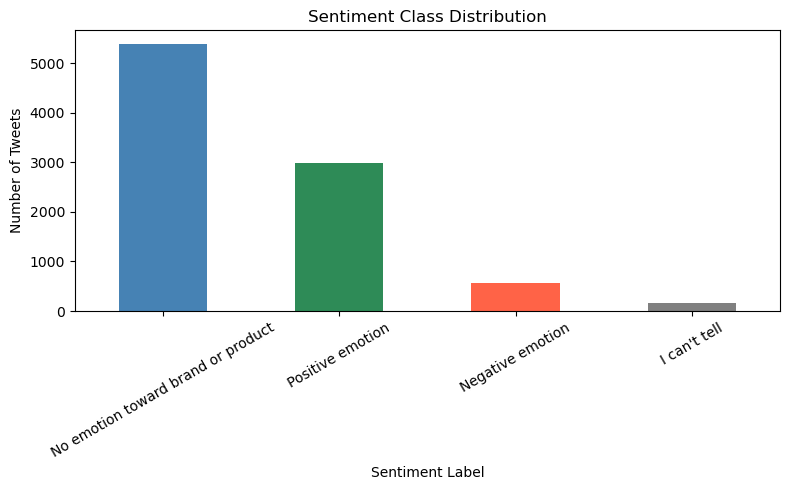

In [8]:
# Visualize the class distribution
fig, ax = plt.subplots(figsize=(8, 5))

df['sentiment'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'seagreen', 'tomato', 'gray'])

ax.set_title('Sentiment Class Distribution')
ax.set_xlabel('Sentiment Label')
ax.set_ylabel('Number of Tweets')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [9]:
# Check the brand/product column
print('Products and brands mentioned:')
print(df['brand_product'].value_counts())

Products and brands mentioned:
brand_product
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64


In [10]:
# Add a tweet length column to understand text characteristics
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)

print('Tweet length statistics:')
print(df['tweet_length'].describe())

Tweet length statistics:
count    9093.000000
mean      104.951061
std        27.207164
min         3.000000
25%        86.000000
50%       109.000000
75%       126.000000
max       178.000000
Name: tweet_length, dtype: float64


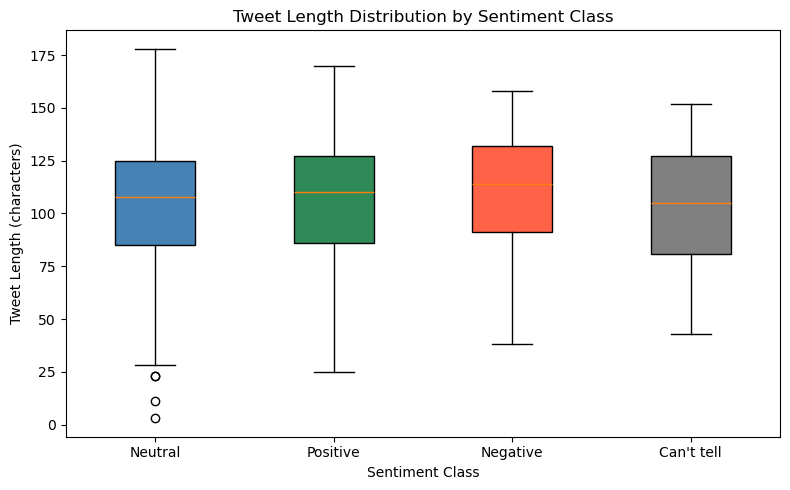

In [11]:
# Visualize tweet length distribution by sentiment class - box plot for clarity
fig, ax = plt.subplots(figsize=(8, 5))

sentiment_order = [
    'No emotion toward brand or product',
    'Positive emotion',
    'Negative emotion',
    'I can\'t tell'
]

data_to_plot = [
    df[df['sentiment'] == label]['tweet_length'].values
    for label in sentiment_order
]

bp = ax.boxplot(data_to_plot, patch_artist=True, labels=['Neutral', 'Positive', 'Negative', "Can't tell"])

colors = ['steelblue', 'seagreen', 'tomato', 'gray']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('Tweet Length Distribution by Sentiment Class')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Tweet Length (characters)')

plt.tight_layout()
plt.show()

---

## Section 4 - Data Preparation

Based on the data understanding above, we apply the following preparation steps:

1. Remove the one row with a missing tweet.
2. Drop the "I can't tell" sentiment class (156 rows) as it is ambiguous and unlearnable.
3. Map the remaining sentiment labels to shorter, cleaner names.
4. Clean the tweet text: remove URLs, mentions, hashtag symbols, punctuation, numbers, and extra whitespace. Convert to lowercase.
5. Remove English stop words during TF-IDF vectorization.

We do not use lemmatization or stemming here to keep the pipeline simple and interpretable, which is appropriate for a proof of concept. This can be revisited if model performance needs to be improved.

In [12]:
# Step 1 - Drop missing tweet text
df = df.dropna(subset=['tweet_text'])
print('Rows after dropping null tweet:', len(df))

Rows after dropping null tweet: 9092


In [13]:
# Step 2 - Remove the "I can't tell" class
df = df[df['sentiment'] != "I can't tell"]
print('Rows after removing ambiguous class:', len(df))
print()
print('Remaining classes:')
print(df['sentiment'].value_counts())

Rows after removing ambiguous class: 8936

Remaining classes:
sentiment
No emotion toward brand or product    5388
Positive emotion                      2978
Negative emotion                       570
Name: count, dtype: int64


In [14]:
# Step 3 - Map sentiment labels to clean short names
label_map = {
    'Positive emotion': 'positive',
    'Negative emotion': 'negative',
    'No emotion toward brand or product': 'neutral'
}

df['sentiment'] = df['sentiment'].map(label_map)

print('Label mapping complete.')
print(df['sentiment'].value_counts())

Label mapping complete.
sentiment
neutral     5388
positive    2978
negative     570
Name: count, dtype: int64


In [15]:
# Step 4 - Define a text cleaning function
def clean_tweet(text):
    """
    Cleans a raw tweet string by:
    - Converting to lowercase
    - Removing URLs
    - Removing @mentions
    - Removing hashtag symbols (keeps the word)
    - Removing punctuation and numbers
    - Stripping extra whitespace
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'#', '', text)                     # remove hashtag symbol
    text = re.sub(r'[^a-z\s]', '', text)              # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra whitespace
    return text

# Apply the cleaning function
df['clean_text'] = df['tweet_text'].apply(clean_tweet)

print('Text cleaning complete. Sample output:')
df[['tweet_text', 'clean_text']].head(5)

Text cleaning complete. Sample output:


,tweet_text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,i have a g iphone after hrs tweeting at riseau...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know about awesome ipadiphone app that youll l...
2,@swonderlin Can not wait for #iPad 2 also. The...,can not wait for ipad also they should sale th...
3,@sxsw I hope this year's festival isn't as cra...,i hope this years festival isnt as crashy as t...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff on fri sxsw marissa mayer google t...


In [16]:
# Confirm the final dataset shape and class balance before modeling
print('Final dataset shape:', df.shape)
print()
print('Class distribution:')
print(df['sentiment'].value_counts())

Final dataset shape: (8936, 5)

Class distribution:
sentiment
neutral     5388
positive    2978
negative     570
Name: count, dtype: int64


---

## Section 5 - Train-Test Split

We split the data into a training set (70%) and a test set (30%) before any modeling takes place. The test set is held out and only used for final evaluation. This ensures that our reported performance metrics reflect how well the model generalizes to unseen tweets, not how well it memorized the training data.

We use `stratify=y` to preserve the class proportions in both the training and test sets, which is important given the imbalanced nature of our target variable.

In [17]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Training set size:', len(X_train))
print('Test set size    :', len(X_test))
print()
print('Training class distribution:')
print(y_train.value_counts())

Training set size: 6255
Test set size    : 2681

Training class distribution:
sentiment
neutral     3771
positive    2085
negative     399
Name: count, dtype: int64
